# 05 · Descriptivos del subcorpus de comportamientos protectores
**Proyecto:** Comportamientos protectores en la esfera pública — análisis de tweets en español  
**Equivalente original:** `6_descriptivos_ciencia.ipynb` + `6_1_nubes_palabras_comparativas.ipynb`

---

### Diferencias con el paper

| Aspecto | Paper | Este notebook |
|---|---|---|
| Unidad | Fragmentos (chunks) de columnas | Tweets completos |
| Metadatos | Autor, Diario | Author_Normalized, Entidad |
| Conteo fragmentos/col | Chunks de ciencia por columna | Tweets de salud por autor |
| Proporción | Ciencia/total chunks por columna | Salud/total tweets por autor |
| Subcategorías | Prefijo `Ciencia_` | Prefijo `Comp_` |
| Tabla reducida | LaTeX (.tex) | Excel (.xlsx) |

**Entradas:**
- `resultadosComportamiento/comportamiento_tweets_final.parquet`
- `resultadosComportamiento/corpus_cleaned.parquet`

**Salidas (figuras):**
- `fig_dist_tweets_comp_por_autor.png`
- `fig_porcentaje_mensual_comportamiento_barras.png`
- `fig_porcentaje_mensual_comportamiento_linea.png`
- `fig_autores_comportamiento_simple.png`
- `fig_autores_comportamiento_comparativo.png`
- `fig_subcategorias_tweets.png`
- `fig_autores_por_subcategoria.png`
- `fig_entidad_comp.png`
- `nube_corpus_general.png`
- `nube_subcorpus_comp.png`

**Salidas (tablas):**
- `subcategorias_tweets.csv`
- `tabla_reducida_frecuencias.xlsx`
- `frecuencias_corpus_lematizado.parquet`
- `frecuencias_comp_lematizado.parquet`
- `tabla_frecuencias_comportamiento.xlsx` (multi-hoja resumen final)


## 0 · Configuración

In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento')

COL_AUTOR   = 'Author_Normalized'
COL_ENTIDAD = 'Entidad'
COL_FECHA   = 'Fecha'

print('[CONFIG] OK')
print(f'  DATA_PROCESSED : {DATA_PROCESSED.resolve()}')


[CONFIG] OK
  DATA_PROCESSED : C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento


## 1 · Imports y carga de datos

In [2]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# Equivalente a: ciencia_chunks.xlsx + corpus_cleaned.xlsx + chunks.parquet
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import spacy, re, subprocess, sys
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('crest')

# Subcorpus de comportamientos protectores + corpus completo
tweets_comp  = pd.read_parquet(DATA_PROCESSED / 'comportamiento_tweets_final.parquet')
corpus       = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')

corpus['Fecha'] = pd.to_datetime(corpus['Fecha'], errors='coerce')

# Merge metadatos al subcorpus de salud
cols_meta = ['id_doc', 'Author_Normalized', 'Entidad', 'Fecha',
             'Texto_limpio', 'Sentimiento', 'Polaridad']
cols_meta = [c for c in cols_meta if c in corpus.columns]

tweets_comp  = tweets_comp.merge(corpus[cols_meta], on='id_doc', how='left')
tweets_comp['Fecha']  = pd.to_datetime(tweets_comp['Fecha'], errors='coerce')
tweets_comp['Anio']  = tweets_comp['Fecha'].dt.year
tweets_comp['Mes']   = tweets_comp['Fecha'].dt.month

print(f'Corpus completo    : {len(corpus):,} tweets')
print(f'Subcorpus comp.    : {len(tweets_comp):,} tweets '
      f'({len(tweets_comp)/len(corpus)*100:.1f}%)')
tweets_comp.head(3)


Corpus completo    : 151,424 tweets
Subcorpus comp.    : 2,804 tweets (1.9%)


,chunk_id,id_doc,texto_chunk,Comp_Desinfectante,Comp_Distanciamiento,Comp_Etiqueta_tos_codo,Comp_Etiqueta_tos_panuelo,Comp_Evitar_reuniones,Comp_Lavado_manos,Comp_Mascarilla,...,etiqueta_comportamiento,categoria_detectada,Author_Normalized,Entidad,Fecha,Texto_limpio,Sentimiento,Polaridad,Anio,Mes
0,17_1,17,A esas horas el covid19 se queda en la casa mi...,0.037909,0.313174,0.314862,0.321228,0.509031,0.192823,0.118177,...,1,Comp_Evitar_reuniones,@elima2219,Sin descripción,2020-06-03,A esas horas el covid19 se queda en la casa mi...,otro,Neutra,2020,6
1,67_1,67,Los vendedores de balones de oxígeno y las pla...,0.253668,0.146621,0.448458,0.501524,0.200239,0.224089,0.342172,...,1,Comp_Etiqueta_tos_panuelo,@cmalcagmailcom1,Sin descripción,2020-06-03,Los vendedores de balones de oxígeno y las pla...,otro,Negativa,2020,6
2,157_1,157,En el barrio La Gloria de Florencia orientamos...,0.112514,0.383266,0.241795,0.235056,0.492450,0.181513,0.160578,...,1,Comp_Evitar_reuniones,@policiacaqueta,"Noticias locales, nacionales o globales",2020-06-03,En el barrio La Gloria de Florencia orientamos...,otro,Neutra,2020,6


## 2 · Estadísticos básicos
Equivalente a las celdas 10–13 del paper.

In [3]:
# ============================================================
# CELL 2 — ESTADISTICOS BASICOS
# Equivalente a celdas 10-13 del paper
# ============================================================

n_total      = len(corpus)
n_comp       = len(tweets_comp)
n_docs_total = corpus['id_doc'].nunique()
n_docs_comp  = tweets_comp['id_doc'].nunique()

print('=' * 55)
print('ESTADISTICOS DEL SUBCORPUS DE COMPORTAMIENTOS')
print('=' * 55)
print(f'  Total tweets en corpus         : {n_total:,}')
print(f'  Tweets con comportamientos     : {n_comp:,}')
# Equivalente a: (7267/62651)*100
print(f'  % tweets comp. / total         : {n_comp/n_total*100:.2f}%')
print(f'  Autores distintos (comp.)      : {tweets_comp[COL_AUTOR].nunique():,}')
print(f'  Autores distintos (corpus)     : {corpus[COL_AUTOR].nunique():,}')
# Equivalente a: (4154/13676)*100
print(f'  % autores con comp. / total    : '
      f'{tweets_comp[COL_AUTOR].nunique()/corpus[COL_AUTOR].nunique()*100:.2f}%')
print(f'  Rango de fechas                : '
      f'{tweets_comp[COL_FECHA].min().date()} -> {tweets_comp[COL_FECHA].max().date()}')
print('=' * 55)


ESTADISTICOS DEL SUBCORPUS DE COMPORTAMIENTOS
  Total tweets en corpus         : 151,424
  Tweets con comportamientos     : 2,804
  % tweets comp. / total         : 1.85%
  Autores distintos (comp.)      : 2,489
  Autores distintos (corpus)     : 79,938
  % autores con comp. / total    : 3.11%
  Rango de fechas                : 2020-03-31 -> 2020-08-18


## 3 · Distribución de tweets de salud por autor
Equivalente a las celdas 14–18 del paper:  
cuántos fragmentos de ciencia tiene cada columna → cuántos tweets de comportamientos tiene cada autor.

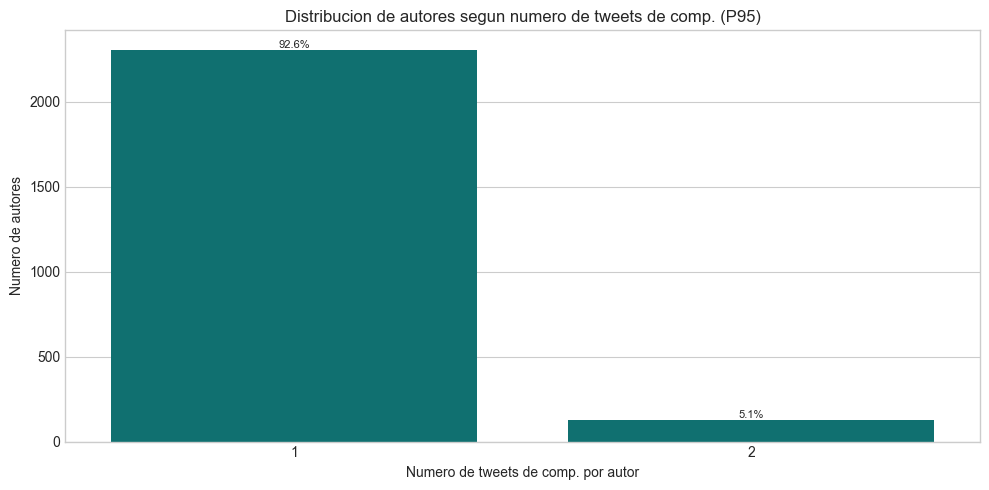

       num_autores  porcentaje
count                         
1             2304       92.57
2              127        5.10
3               34        1.37
4               10        0.40
5                4        0.16
6                6        0.24
7                1        0.04
8                1        0.04
9                1        0.04
24               1        0.04


In [4]:
# ============================================================
# CELL 3 — TWEETS DE COMP. POR AUTOR
# Equivalente a celdas 14-15 del paper
# ============================================================

# Cuantos tweets de comportamientos tiene cada autor (equiv. cuántos chunks de ciencia por columna)
conteo_por_autor = tweets_comp[COL_AUTOR].value_counts().reset_index()
conteo_por_autor.columns = [COL_AUTOR, 'num_tweets_comp']

# Distribucion: cuantos autores tienen 1, 2, 3... tweets de salud (equiv. cell 15)
distribucion = tweets_comp[COL_AUTOR].value_counts().value_counts().sort_index()
porcentajes_dist = distribucion / distribucion.sum() * 100

# Solo mostrar hasta el percentil 95 para que el grafico sea legible
p95 = int(np.percentile(conteo_por_autor['num_tweets_comp'], 95))
dist_plot = distribucion[distribucion.index <= p95]
pct_plot  = porcentajes_dist[porcentajes_dist.index <= p95]

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=dist_plot.index, y=dist_plot.values, color='teal')
for i, (x, y) in enumerate(zip(dist_plot.index, dist_plot.values)):
    ax.text(i, y + 0.5, f'{pct_plot.iloc[i]:.1f}%', ha='center', va='bottom', fontsize=8)
plt.title('Distribucion de autores segun numero de tweets de comp. (P95)')
plt.xlabel('Numero de tweets de comp. por autor')
plt.ylabel('Numero de autores')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_dist_tweets_comp_por_autor.png', dpi=300)
plt.show()

print(distribucion.head(10).to_frame('num_autores').assign(porcentaje=porcentajes_dist.head(10).round(2)))


In [5]:
# ============================================================
# CELL 4 — PROPORCION COMP / TOTAL POR AUTOR
# Equivalente a celdas 16-18 del paper (proporcion ciencia/chunks por columna)
# ============================================================

tweets_por_autor_total = corpus[COL_AUTOR].value_counts().reset_index()
tweets_por_autor_total.columns = [COL_AUTOR, 'num_tweets_total']

df_ratio = conteo_por_autor.merge(tweets_por_autor_total, on=COL_AUTOR, how='left')
df_ratio['proporcion_comp'] = df_ratio['num_tweets_comp'] / df_ratio['num_tweets_total']

print('Estadisticos de proporcion de comp. por autor:')
print(df_ratio['proporcion_comp'].describe().round(4))

promedio_tweets_total  = df_ratio['num_tweets_total'].mean()
promedio_tweets_comp   = df_ratio['num_tweets_comp'].mean()
promedio_prop_comp     = df_ratio['proporcion_comp'].mean()

print(f'\nPromedio de tweets totales por autor  : {promedio_tweets_total:.2f}')
print(f'Promedio de tweets de comp. por autor  : {promedio_tweets_comp:.2f}')
print(f'Promedio de proporcion de comp.        : {promedio_prop_comp*100:.2f}%')


Estadisticos de proporcion de comp. por autor:
count    2489.0000
mean        0.6144
std         0.3817
min         0.0067
25%         0.2500
50%         0.5000
75%         1.0000
max         1.0000
Name: proporcion_comp, dtype: float64

Promedio de tweets totales por autor  : 5.52
Promedio de tweets de comp. por autor  : 1.13
Promedio de proporcion de comp.        : 61.44%


## 4 · Distribución temporal
Equivalente a las celdas 20–21 del paper.

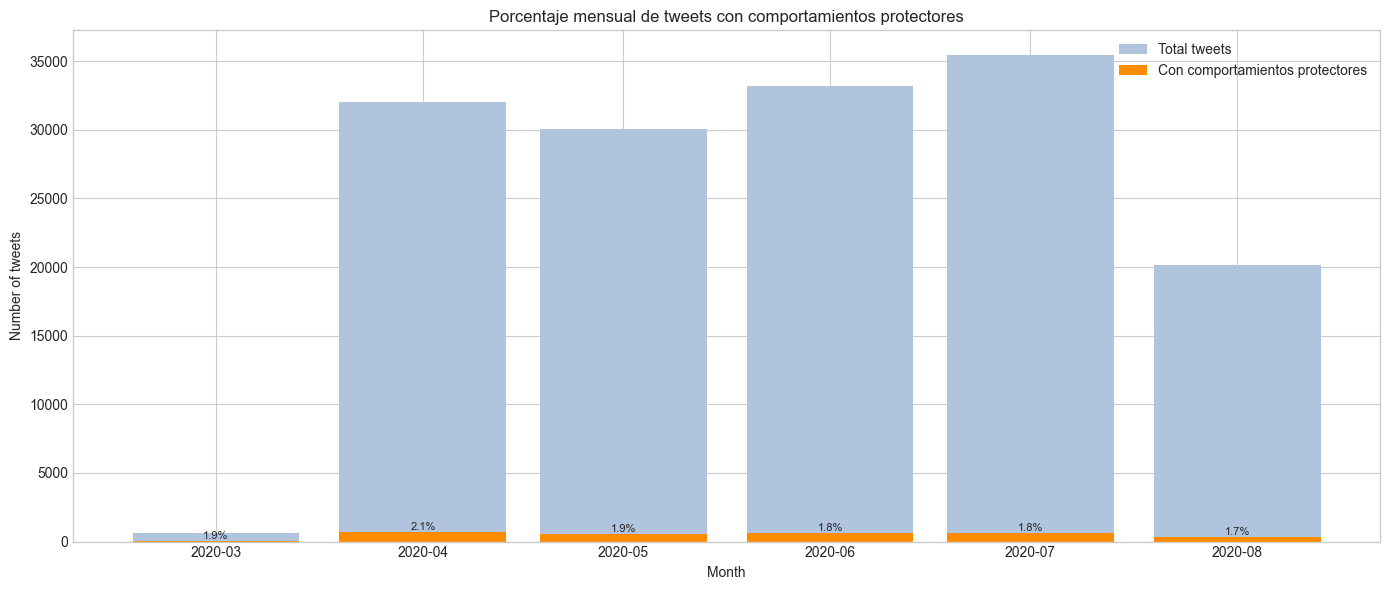

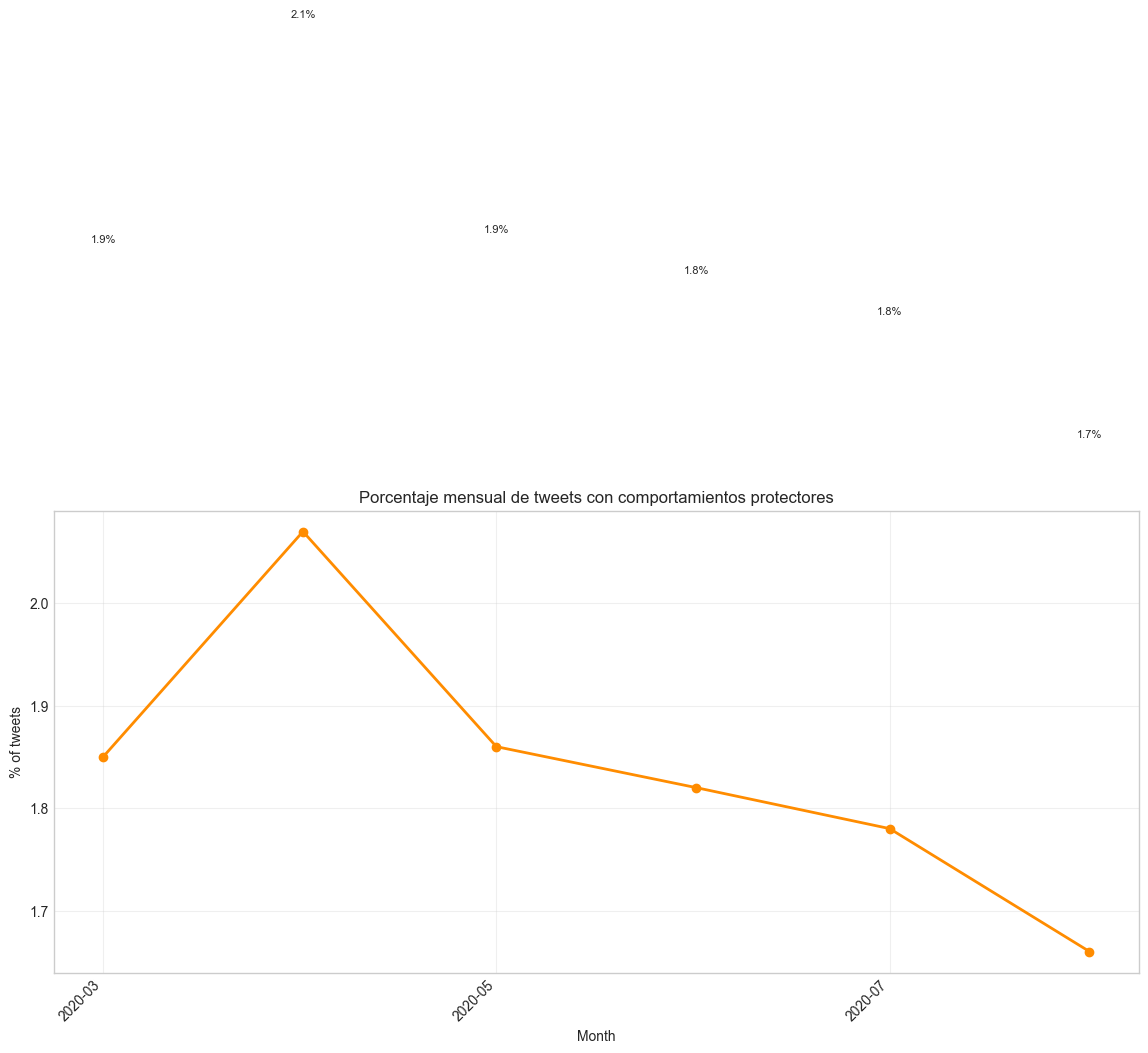

,total_tweets,tweets_comp,porcentaje
AnoMes,,,
2020-03-01,593,11,1.85
2020-04-01,32000,662,2.07
2020-05-01,30048,559,1.86
2020-06-01,33193,605,1.82
2020-07-01,35469,632,1.78
2020-08-01,20121,335,1.66


In [6]:
# ============================================================
# CELL 5 — DISTRIBUCION TEMPORAL
# Equivalente a celdas 20-21 del paper
# ============================================================

corpus['AnoMes']       = corpus[COL_FECHA].dt.to_period('M')
tweets_comp['AnoMes']  = tweets_comp[COL_FECHA].dt.to_period('M')

totales   = corpus.groupby('AnoMes')['id_doc'].nunique()
con_comp  = tweets_comp.groupby('AnoMes')['id_doc'].nunique()

mensual = pd.DataFrame({'total_tweets': totales, 'tweets_comp': con_comp}).fillna(0)
mensual['porcentaje'] = (mensual['tweets_comp'] / mensual['total_tweets'] * 100).round(2)
mensual.index = mensual.index.to_timestamp()

# Grafica 1: barras apiladas
plt.figure(figsize=(14, 6))
plt.bar(mensual.index, mensual['total_tweets'],
        color='lightsteelblue', label='Total tweets', width=25)
plt.bar(mensual.index, mensual['tweets_comp'],
        color='darkorange', label='Con comportamientos protectores', width=25)
for x, y_s, pct in zip(mensual.index, mensual['tweets_comp'], mensual['porcentaje']):
    if y_s > 0:
        plt.text(x, y_s + 2, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
plt.title('Porcentaje mensual de tweets con comportamientos protectores')
plt.ylabel('Number of tweets')
plt.xlabel('Month')
plt.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_porcentaje_mensual_comportamiento_barras.png', dpi=300)
plt.show()

# Grafica 2: linea de porcentaje
plt.figure(figsize=(14, 6))
plt.plot(mensual.index, mensual['porcentaje'], marker='o', linestyle='-', color='darkorange', linewidth=2)
for x, y in zip(mensual.index, mensual['porcentaje']):
    if not np.isnan(y):
        plt.text(x, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=8)
plt.title('Porcentaje mensual de tweets con comportamientos protectores')
plt.ylabel('% of tweets')
plt.xlabel('Month')
plt.grid(alpha=0.3)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_porcentaje_mensual_comportamiento_linea.png', dpi=300)
plt.show()
mensual.tail(10)


## 5 · Autores con más tweets de salud
Equivalente a las celdas 22–25 del paper.

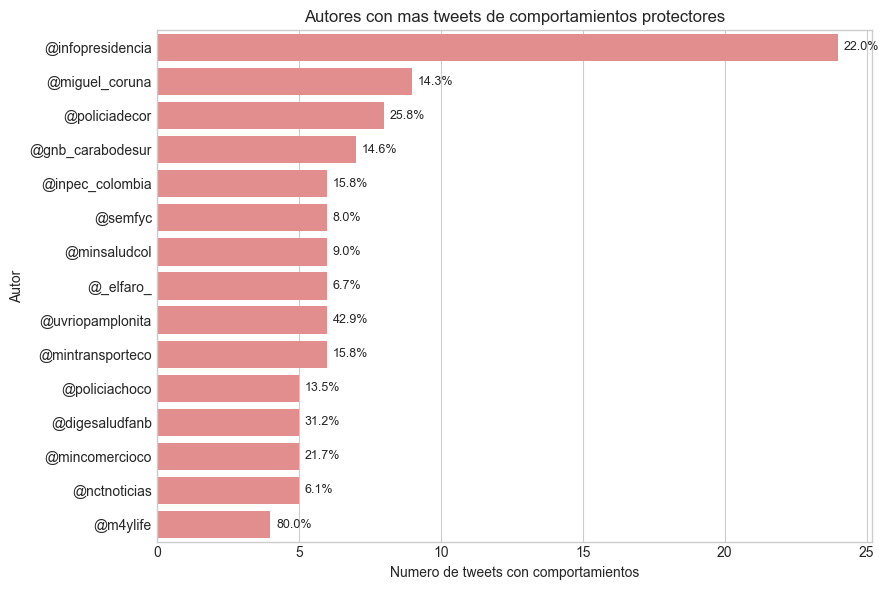

In [7]:
# ============================================================
# CELL 6 — TOP AUTORES (gráfico simple, equiv. cell 23)
# ============================================================

autores_comp  = (tweets_comp.groupby(COL_AUTOR)['id_doc'].nunique()
    .sort_values(ascending=False).reset_index(name='n_tweets_comp'))
autores_total = (corpus.groupby(COL_AUTOR)['id_doc'].nunique()
    .reset_index(name='total_columnas'))
autores_merge = autores_comp.merge(autores_total, on=COL_AUTOR, how='left')
autores_merge['porcentaje_comp'] = (
    autores_merge['n_tweets_comp'] / autores_merge['total_columnas'] * 100).round(2)

top_autores = autores_merge.head(15)

plt.figure(figsize=(9, 6))
orden = top_autores.sort_values('n_tweets_comp', ascending=False)[COL_AUTOR]
sns.barplot(data=top_autores, y=COL_AUTOR, x='n_tweets_comp', order=orden, color='lightcoral')
for i, (n, p) in enumerate(zip(top_autores['n_tweets_comp'], top_autores['porcentaje_comp'])):
    plt.text(n + 0.2, i, f'{p:.1f}%', va='center', fontsize=9)
plt.title('Autores con mas tweets de comportamientos protectores')
plt.xlabel('Numero de tweets con comportamientos')
plt.ylabel('Autor')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_autores_comportamiento_simple.png', dpi=300)
plt.show()


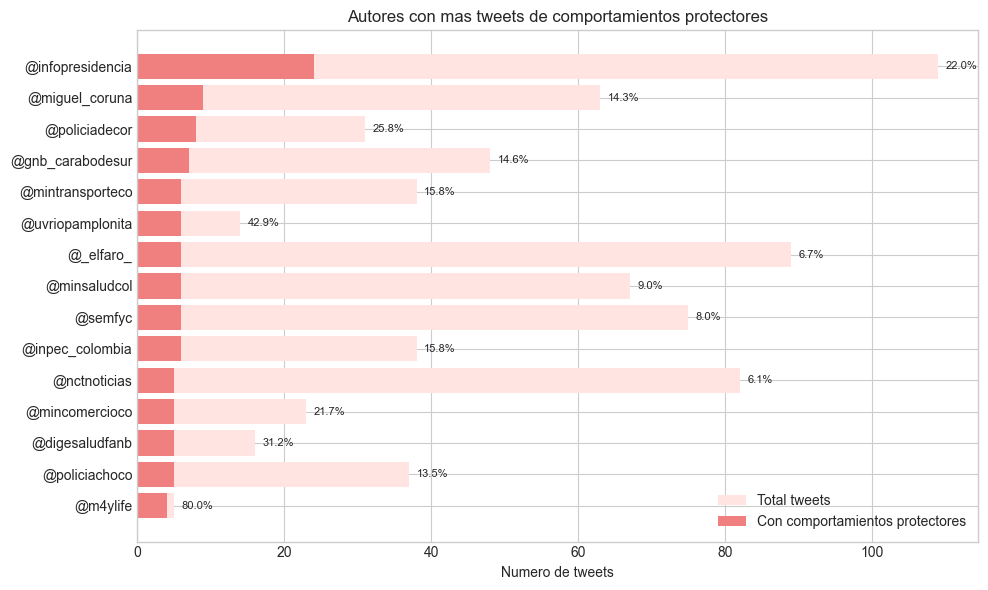

,Author_Normalized,n_tweets_comp,total_columnas,porcentaje_comp
0,@infopresidencia,24,109,22.02
1,@miguel_coruna,9,63,14.29
2,@policiadecor,8,31,25.81
3,@gnb_carabodesur,7,48,14.58
4,@inpec_colombia,6,38,15.79
5,@semfyc,6,75,8.00
6,@minsaludcol,6,67,8.96
7,@_elfaro_,6,89,6.74
8,@uvriopamplonita,6,14,42.86
9,@mintransporteco,6,38,15.79


In [8]:
# ============================================================
# CELL 7 — TOP AUTORES (gráfico comparativo total vs salud, equiv. cell 24)
# ============================================================

top_sorted = top_autores.sort_values('n_tweets_comp', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_sorted[COL_AUTOR], top_sorted['total_columnas'],
         color='mistyrose', label='Total tweets')
plt.barh(top_sorted[COL_AUTOR], top_sorted['n_tweets_comp'],
         color='lightcoral', label='Con comportamientos protectores')
for i, (n, t, p) in enumerate(zip(
    top_sorted['n_tweets_comp'], top_sorted['total_columnas'], top_sorted['porcentaje_comp']
)):
    plt.text(t + 1, i, f'{p:.1f}%', va='center', fontsize=8)
plt.title('Autores con mas tweets de comportamientos protectores')
plt.xlabel('Numero de tweets')
plt.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_autores_comportamiento_comparativo.png', dpi=300)
plt.show()
top_autores


## 6 · Por subcategorías
Equivalente a las celdas 26–31 del paper.

TABLA DE SUBCATEGORIAS DE COMPORTAMIENTOS
Total tweets de comportamientos: 2,804
------------------------------------------------------------
             Subcategoria  N_tweets  Porcentaje
    Comp_Evitar_reuniones      1193       42.55
   Comp_Etiqueta_tos_codo       775       27.64
Comp_Etiqueta_tos_panuelo       313       11.16
        Comp_Lavado_manos       264        9.42
          Comp_Mascarilla       144        5.14
     Comp_Distanciamiento        76        2.71
       Comp_Desinfectante        39        1.39


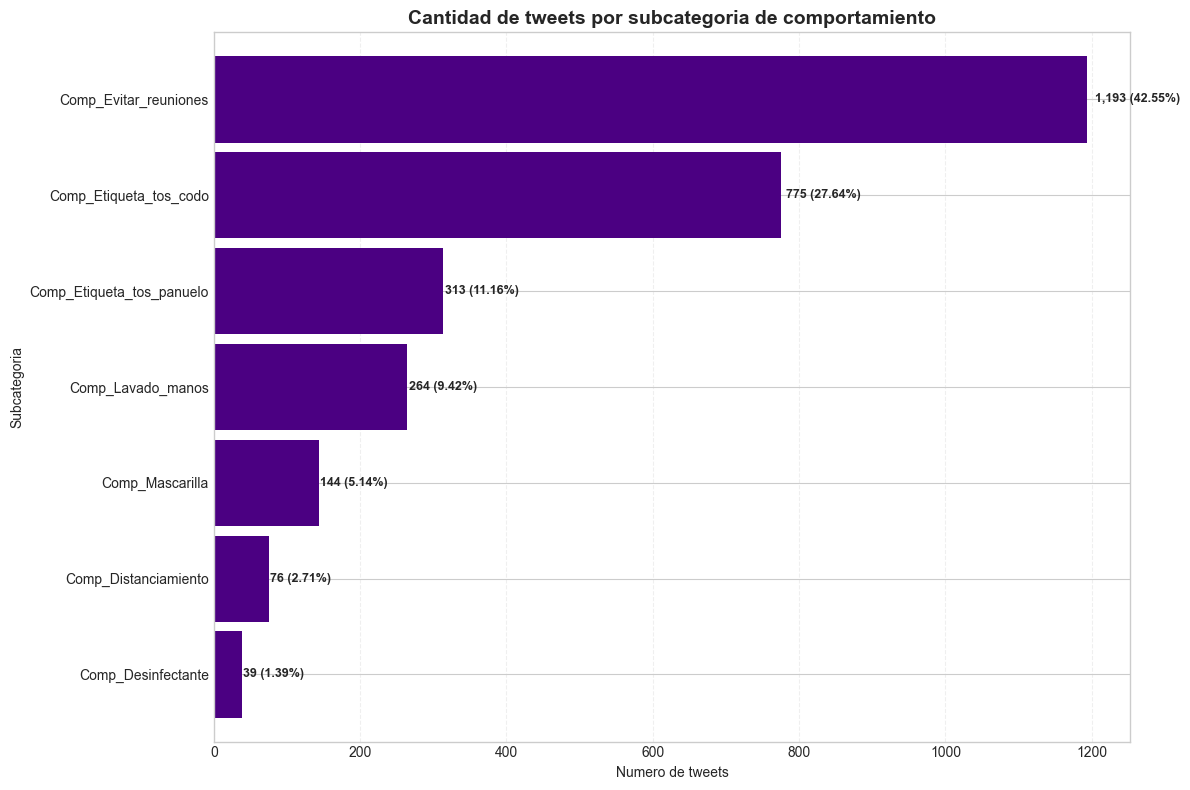

[GUARDADO] subcategorias_tweets.csv


In [9]:
# ============================================================
# CELL 8 — SUBCATEGORIAS: barplot + tabla + CSV (equiv. cells 28-30)
# ============================================================

subcats_cols = [c for c in tweets_comp.columns if c.startswith('Comp_')]
tweets_comp['subcategoria_max']  = tweets_comp[subcats_cols].idxmax(axis=1)

conteos     = tweets_comp['subcategoria_max'].value_counts()
total_s     = conteos.sum()
porcentajes = (conteos / total_s * 100).round(2)

tabla_subcats = pd.DataFrame({
    'Subcategoria': conteos.index,
    'N_tweets'    : conteos.values,
    'Porcentaje'  : porcentajes.values,
}).sort_values('N_tweets', ascending=False)

print('=' * 60)
print('TABLA DE SUBCATEGORIAS DE COMPORTAMIENTOS')
print('=' * 60)
print(f'Total tweets de comportamientos: {total_s:,}')
print('-' * 60)
print(tabla_subcats.to_string(index=False))

# Grafico
conteos_ord = conteos.sort_values(ascending=True)
plt.figure(figsize=(12, 8))
ax = conteos_ord.plot.barh(color='indigo', width=0.9)
for i, (v, pct) in enumerate(zip(
    conteos_ord.values, porcentajes[conteos_ord.index].values
)):
    ax.text(v + v*0.01, i, f'{v:,} ({pct}%)', va='center', fontsize=9, fontweight='bold')
plt.title('Cantidad de tweets por subcategoria de comportamiento', fontsize=14, fontweight='bold')
plt.xlabel('Numero de tweets')
plt.ylabel('Subcategoria')
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_subcategorias_tweets.png', dpi=300)
plt.show()

# Guardar CSV (equiv. Karen: subcategorias_cientificas.csv)
tabla_subcats.to_csv(DATA_PROCESSED / 'subcategorias_tweets.csv', index=False, encoding='utf-8-sig')
print('[GUARDADO] subcategorias_tweets.csv')


Autores distintos por subcategoria:
subcategoria_max
Comp_Evitar_reuniones        1062
Comp_Etiqueta_tos_codo        731
Comp_Etiqueta_tos_panuelo     307
Comp_Lavado_manos             241
Comp_Mascarilla               136
Comp_Distanciamiento           76
Comp_Desinfectante             38


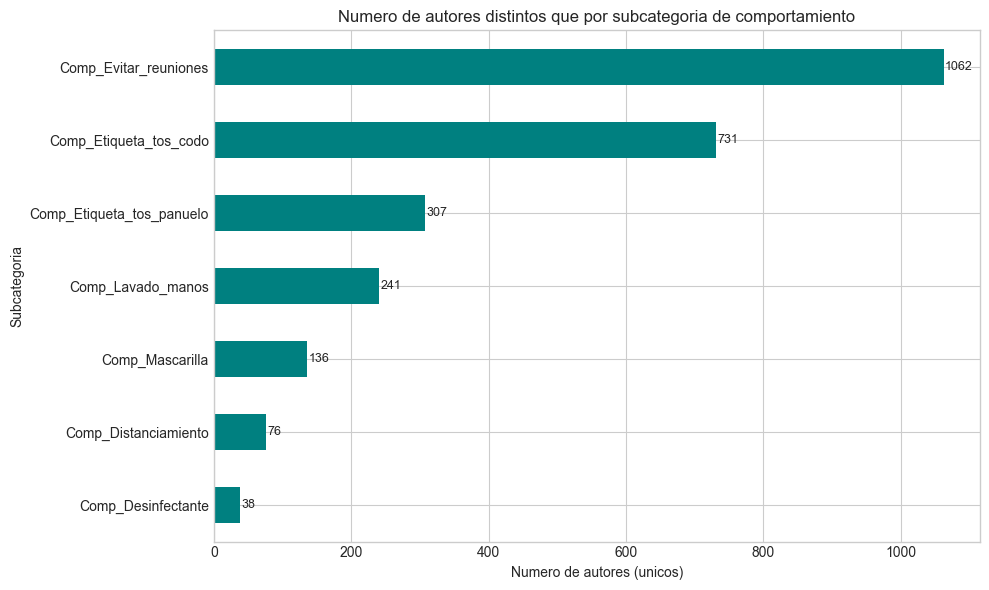

In [10]:
# ============================================================
# CELL 9 — AUTORES POR SUBCATEGORIA (equiv. cell 31)
# ============================================================

autores_por_subcat = (
    tweets_comp.groupby('subcategoria_max')[COL_AUTOR]
    .nunique().sort_values(ascending=False)
)

print('Autores distintos por subcategoria:')
print(autores_por_subcat.to_string())

plt.figure(figsize=(10, 6))
ax = autores_por_subcat.sort_values().plot.barh(color='teal')
for i, v in enumerate(autores_por_subcat.sort_values().values):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)
plt.title('Numero de autores distintos que por subcategoria de comportamiento')
plt.xlabel('Numero de autores (unicos)')
plt.ylabel('Subcategoria')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_autores_por_subcategoria.png', dpi=300)
plt.show()


## 7 · Distribución por tipo de cuenta
Equivalente adicional — reemplaza distribución por diario.

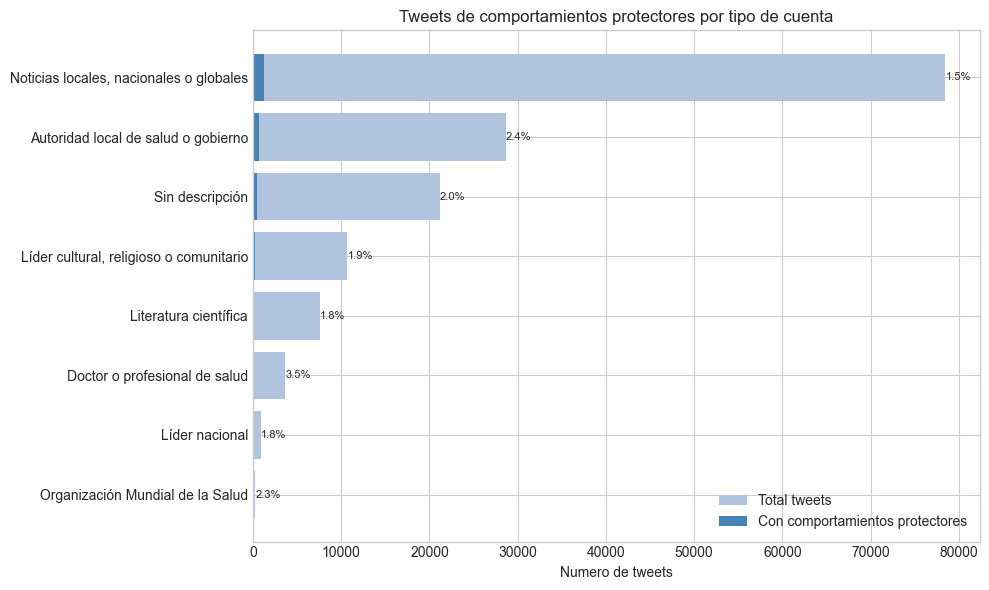

,Entidad,n_comp,n_total,pct_comp
5,"Noticias locales, nacionales o globales",1205,78475,1.5
0,Autoridad local de salud o gobierno,683,28684,2.4
7,Sin descripción,431,21195,2.0
3,"Líder cultural, religioso o comunitario",201,10705,1.9
2,Literatura científica,133,7554,1.8
1,Doctor o profesional de salud,129,3677,3.5
4,Líder nacional,16,874,1.8
6,Organización Mundial de la Salud,6,260,2.3


In [11]:
# ============================================================
# CELL 10 — POR TIPO DE CUENTA (Entidad)
# ============================================================

entidad_comp  = tweets_comp.groupby(COL_ENTIDAD)['id_doc'].nunique().reset_index(name='n_comp')
entidad_total = corpus.groupby(COL_ENTIDAD)['id_doc'].nunique().reset_index(name='n_total')
entidad_merge = entidad_comp.merge(entidad_total, on=COL_ENTIDAD, how='left')
entidad_merge['pct_comp']  = (entidad_merge['n_comp'] / entidad_merge['n_total'] * 100).round(1)
entidad_merge = entidad_merge.sort_values('n_comp', ascending=False)

top_ent = entidad_merge.sort_values('n_comp', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(top_ent[COL_ENTIDAD], top_ent['n_total'], color='lightsteelblue', label='Total tweets')
plt.barh(top_ent[COL_ENTIDAD], top_ent['n_comp'], color='steelblue', label='Con comportamientos protectores')
for i, (n, t, p) in enumerate(zip(top_ent['n_comp'], top_ent['n_total'], top_ent['pct_comp'])):
    plt.text(t + 1, i, f'{p:.1f}%', va='center', fontsize=8)
plt.title('Tweets de comportamientos protectores por tipo de cuenta')
plt.xlabel('Numero de tweets')
plt.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_entidad_comp.png', dpi=300)
plt.show()
entidad_merge


## 8 · Nubes de palabras
Equivalente a las celdas 32–34 del paper + `6_1_nubes_palabras_comparativas.ipynb`.

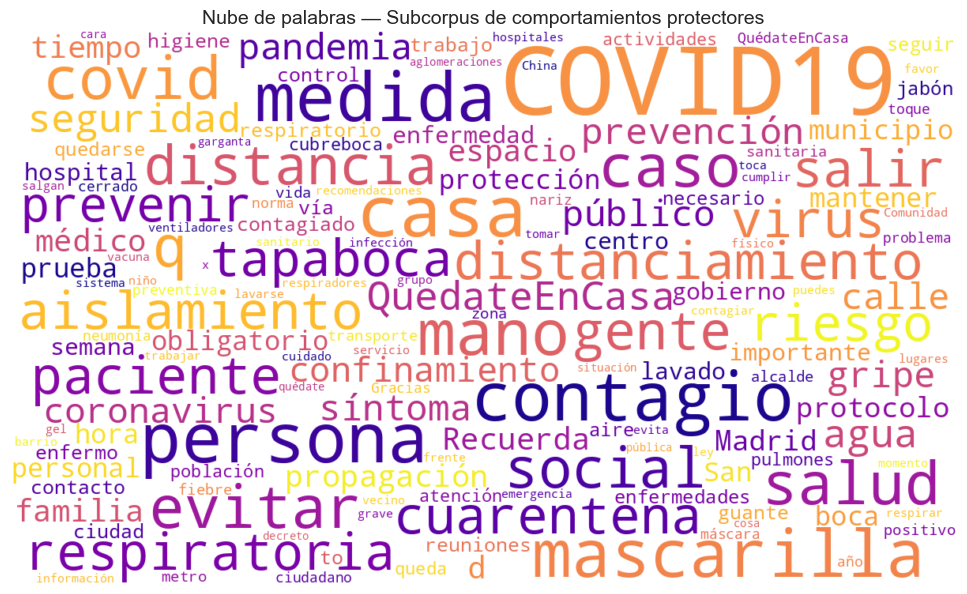

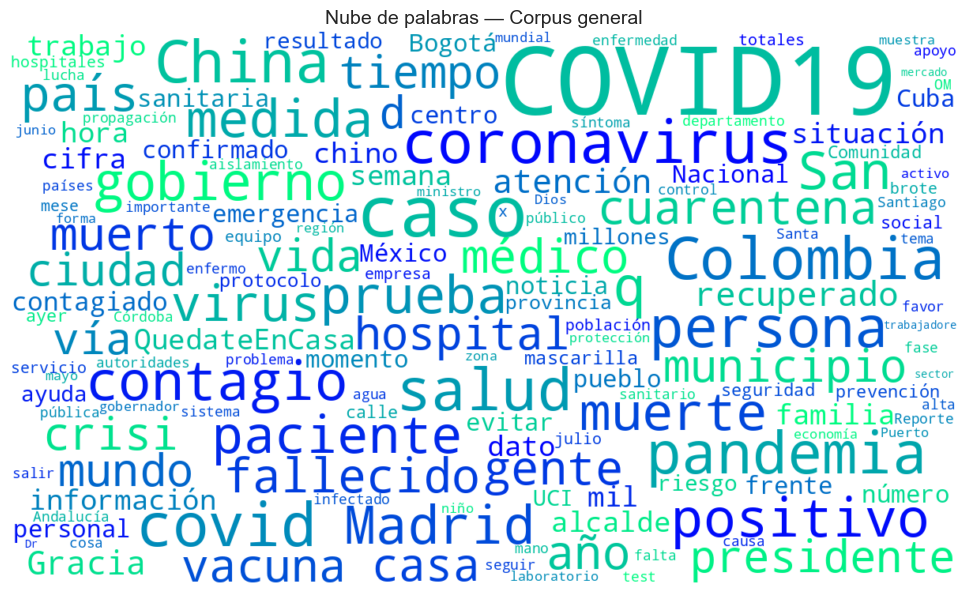

[GUARDADO] nube_subcorpus_comp.png  +  nube_corpus_general.png


In [12]:
# ============================================================
# CELL 11 — NUBES DE PALABRAS
# Equivalente a celdas 33-34 del paper
# ============================================================

subprocess.run([sys.executable, '-m', 'spacy', 'download', 'es_core_news_sm'], capture_output=True)
nlp = spacy.load('es_core_news_sm')
STOP_WORDS = nlp.Defaults.stop_words

WC_PARAMS = dict(
    width=1200, height=700, background_color='white',
    stopwords=STOP_WORDS, max_words=150,
    collocations=False, prefer_horizontal=1.0,
    relative_scaling=0.3, max_font_size=120, min_font_size=8,
    random_state=42,
)

# Nube 1: subcorpus de salud (equiv. nube de fragmentos de ciencia)
texto_comp  = ' '.join(tweets_comp['Texto_limpio'].dropna())
wc_comp  = WordCloud(**WC_PARAMS, colormap='plasma').generate(texto_comp)
plt.figure(figsize=(10, 6))
plt.imshow(wc_comp, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras — Subcorpus de comportamientos protectores', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'nube_subcorpus_comp.png', dpi=300)
plt.show()

# Nube 2: corpus general (adicional comparativo)
texto_general = ' '.join(corpus['Texto_limpio'].dropna())
wc_general = WordCloud(**WC_PARAMS, colormap='winter').generate(texto_general)
plt.figure(figsize=(10, 6))
plt.imshow(wc_general, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras — Corpus general', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'nube_corpus_general.png', dpi=300)
plt.show()
print('[GUARDADO] nube_subcorpus_comp.png  +  nube_corpus_general.png')


## 9 · Tablas de palabras más frecuentes
Equivalente a las celdas 35–37 del paper.

In [13]:
# ============================================================
# CELL 12 — FUNCION obtener_frecuencias
# Replica exacta de utils.obtener_frecuencias() del paper
# ============================================================

from tqdm import tqdm

def obtener_frecuencias(textos, stopwords, n=None, lematizar=False):
    """Replica de utils.obtener_frecuencias() del paper."""
    texto_unido = ' '.join(map(str, textos)).lower()
    tokens = re.findall(r'\b[a-záéíóúüñ]+\b', texto_unido)  # mismo regex que Karen
    tokens = [t for t in tokens if t not in stopwords and len(t) > 2]

    if not lematizar:
        return Counter(tokens).most_common(n)

    print('Lematizando textos...')
    lemas = []
    for doc in tqdm(nlp.pipe(tokens, batch_size=500, disable=['ner','parser'], n_process=2),
                    total=len(tokens), desc='Lematizando'):
        lemas.extend([t.lemma_.lower() for t in doc if t.is_alpha and len(t) > 2])
    return Counter([l for l in lemas if l not in stopwords]).most_common(n)


In [14]:
# ============================================================
# CELL 13 — FRECUENCIAS SIN LEMATIZAR (equiv. cell 37)
# corpus + comp + cuentas_con_comp
# ============================================================

autores_con_comp  = tweets_comp[COL_AUTOR].unique()
textos_cuentas_comp  = corpus[corpus[COL_AUTOR].isin(autores_con_comp)]['Texto_limpio']

df_corpus_freq = pd.DataFrame(
    obtener_frecuencias(corpus['Texto_limpio'], STOP_WORDS, n=None),
    columns=['palabra', 'frecuencia_corpus']
)
df_comp_freq = pd.DataFrame(
    obtener_frecuencias(tweets_comp['Texto_limpio'], STOP_WORDS, n=None),
    columns=['palabra', 'frecuencia_comp']
)
df_cuentas_freq = pd.DataFrame(
    obtener_frecuencias(textos_cuentas_comp, STOP_WORDS, n=None),
    columns=['palabra', 'frecuencia_cuentas']
)

tabla_frecuencias = (
    df_corpus_freq
    .merge(df_comp_freq, on='palabra', how='outer')
    .merge(df_cuentas_freq, on='palabra', how='outer')
    .fillna(0)
)
tabla_frecuencias[['frecuencia_corpus','frecuencia_comp','frecuencia_cuentas']] = (
    tabla_frecuencias[['frecuencia_corpus','frecuencia_comp','frecuencia_cuentas']].astype(int)
)
tabla_frecuencias['proporcion_comp'] = tabla_frecuencias.apply(
    lambda r: r['frecuencia_comp'] / r['frecuencia_corpus'] if r['frecuencia_corpus'] > 0 else 0, axis=1
)
tabla_frecuencias['proporcion_cuentas'] = tabla_frecuencias.apply(
    lambda r: r['frecuencia_cuentas'] / r['frecuencia_corpus'] if r['frecuencia_corpus'] > 0 else 0, axis=1
)

tabla_top = tabla_frecuencias.sort_values('frecuencia_comp', ascending=False).head(30)
tabla_top.head(20)


,palabra,frecuencia_corpus,frecuencia_comp,frecuencia_cuentas,proporcion_comp,proporcion_cuentas
19462,casa,3324,345,598,0.103791,0.179904
90427,personas,7876,286,1021,0.036313,0.129634
76284,medidas,5771,256,963,0.044360,0.166869
74507,manos,1054,254,327,0.240987,0.310247
28046,contagio,3422,226,600,0.066043,0.175336
30223,covid,11314,217,471,0.019180,0.041630
106511,salud,10454,216,1279,0.020662,0.122346
48755,evitar,2433,212,589,0.087135,0.242088
110914,social,2104,172,346,0.081749,0.164449
75388,mascarilla,1013,159,220,0.156960,0.217177


## 10 · Tabla reducida para el artículo
Equivalente a la celda 38 del paper (Karen guarda LaTeX; aquí guardamos Excel).

In [15]:
# ============================================================
# CELL 14 — TABLA REDUCIDA PARA EL ARTICULO (equiv. cell 38)
# Karen: LaTeX (.tex)  →  aqui: Excel (.xlsx)
# ============================================================

tabla_reducida = tabla_top[['palabra','frecuencia_corpus','frecuencia_cuentas','proporcion_cuentas']].copy()
tabla_reducida['proporcion_cuentas'] = tabla_reducida['proporcion_cuentas'].round(2)
tabla_reducida = tabla_reducida.rename(columns={
    'palabra'           : 'Palabra',
    'frecuencia_corpus' : 'Freq. corpus',
    'frecuencia_cuentas': 'Freq. cuentas con comportamientos',
    'proporcion_cuentas': 'Proporcion cuentas',
})

ruta_reducida = DATA_PROCESSED / 'tabla_reducida_frecuencias.xlsx'
tabla_reducida.to_excel(ruta_reducida, index=False, engine='openpyxl')
print(f'[GUARDADO] tabla_reducida_frecuencias.xlsx')
tabla_reducida


[GUARDADO] tabla_reducida_frecuencias.xlsx


,Palabra,Freq. corpus,Freq. cuentas con comportamientos,Proporcion cuentas
19462,casa,3324,598,0.18
90427,personas,7876,1021,0.13
76284,medidas,5771,963,0.17
74507,manos,1054,327,0.31
28046,contagio,3422,600,0.18
30223,covid,11314,471,0.04
106511,salud,10454,1279,0.12
48755,evitar,2433,589,0.24
110914,social,2104,346,0.16
75388,mascarilla,1013,220,0.22


## 11 · Frecuencias lematizadas *(opcional)*
Equivalente a las celdas 39–44 del paper.

> **Antes de correr:** elige una opción:
> - `LEMATIZAR = False` + `CARGAR = True` → carga desde parquet si ya existen
> - `LEMATIZAR = True`  + `CARGAR = False` → recalcula (puede tardar varios minutos)


In [16]:
# ============================================================
# CELL 15 — FRECUENCIAS LEMATIZADAS (equiv. cells 41-42)
# ============================================================

LEMATIZAR = False   # True para recalcular
CARGAR    = True    # True para cargar desde parquet si existe

ruta_corpus_lem = DATA_PROCESSED / 'frecuencias_corpus_lematizado.parquet'
ruta_comp_lem   = DATA_PROCESSED / 'frecuencias_comp_lematizado.parquet'

if CARGAR and ruta_corpus_lem.exists() and ruta_comp_lem.exists():
    df_corpus_lem = pd.read_parquet(ruta_corpus_lem)
    df_comp_lem   = pd.read_parquet(ruta_comp_lem)
    print('Frecuencias lematizadas cargadas desde parquet')
elif LEMATIZAR:
    df_corpus_lem = pd.DataFrame(
        obtener_frecuencias(corpus['Texto_limpio'], STOP_WORDS, n=None, lematizar=True),
        columns=['palabra', 'frecuencia_corpus']
    )
    df_comp_lem = pd.DataFrame(
        obtener_frecuencias(tweets_comp['Texto_limpio'], STOP_WORDS, n=None, lematizar=True),
        columns=['palabra', 'frecuencia_comp']
    )
    print('Frecuencias lematizadas calculadas')
else:
    print('Skipped: establece LEMATIZAR=True o CARGAR=True')
    df_corpus_lem = df_corpus_freq.rename(columns={'frecuencia_corpus':'frecuencia_corpus'})
    df_comp_lem   = df_comp_freq.rename(columns={'frecuencia_comp':'frecuencia_comp'})


Skipped: establece LEMATIZAR=True o CARGAR=True


In [17]:
# ============================================================
# CELL 16 — MERGE LEMATIZADO (equiv. cell 43)
# ============================================================

tabla_lem = (
    df_corpus_lem.merge(df_comp_lem, on='palabra', how='outer').fillna(0)
)
for col in ['frecuencia_corpus','frecuencia_comp']:
    if col in tabla_lem.columns:
        tabla_lem[col] = tabla_lem[col].astype(int)

if 'frecuencia_corpus' in tabla_lem and 'frecuencia_comp' in tabla_lem:
    tabla_lem['proporcion_comp'] = tabla_lem.apply(
        lambda r: r['frecuencia_comp'] / r['frecuencia_corpus'] if r['frecuencia_corpus'] > 0 else 0,
        axis=1
    )

tabla_lem_top = tabla_lem.sort_values('frecuencia_comp', ascending=False)
tabla_lem_top.head(10)


,palabra,frecuencia_corpus,frecuencia_comp,proporcion_comp
19462,casa,3324,345,0.103791
90427,personas,7876,286,0.036313
76284,medidas,5771,256,0.044360
74507,manos,1054,254,0.240987
28046,contagio,3422,226,0.066043
30223,covid,11314,217,0.019180
106511,salud,10454,216,0.020662
48755,evitar,2433,212,0.087135
110914,social,2104,172,0.081749
75388,mascarilla,1013,159,0.156960


In [18]:
# ============================================================
# CELL 17 — GUARDAR LEMATIZADOS EN PARQUET (equiv. cell 44)
# ============================================================

if LEMATIZAR:
    df_corpus_lem.to_parquet(ruta_corpus_lem, index=False)
    df_comp_lem.to_parquet(ruta_comp_lem, index=False)
    print('[GUARDADO] frecuencias_corpus_lematizado.parquet')
    print('[GUARDADO] frecuencias_comp_lematizado.parquet')
else:
    print('Skipped (LEMATIZAR=False)')


Skipped (LEMATIZAR=False)


In [19]:
# ============================================================
# CELL 18 — PALABRAS CON ALTA PROPORCION (equiv. cell 46)
# Karen: tabla_top[tabla_top['proporcion_columnas'] > 0.6]
# ============================================================

prop_base   = len(tweets_comp) / len(corpus)
umbral_prop = prop_base * 1.5

palabras_comp = (
    tabla_frecuencias[
        (tabla_frecuencias['proporcion_comp'] > umbral_prop) &
        (tabla_frecuencias['frecuencia_comp'] >= 10)
    ]
    .sort_values('frecuencia_comp', ascending=False)
    .head(30)
)

print(f'Proporcion base: {prop_base:.3f}  |  Umbral: {umbral_prop:.3f}')
print(f'Palabras con alta asociacion a comportamientos: {len(palabras_comp)}')
palabras_comp


Proporcion base: 0.019  |  Umbral: 0.028
Palabras con alta asociacion a comportamientos: 30


,palabra,frecuencia_corpus,frecuencia_comp,frecuencia_cuentas,proporcion_comp,proporcion_cuentas
19462,casa,3324,345,598,0.103791,0.179904
90427,personas,7876,286,1021,0.036313,0.129634
76284,medidas,5771,256,963,0.044360,0.166869
74507,manos,1054,254,327,0.240987,0.310247
28046,contagio,3422,226,600,0.066043,0.175336
48755,evitar,2433,212,589,0.087135,0.242088
110914,social,2104,172,346,0.081749,0.164449
75388,mascarilla,1013,159,220,0.156960,0.217177
39555,distancia,751,149,224,0.198402,0.298269
75396,mascarillas,1164,149,244,0.128007,0.209622


## 12 · Guardar todas las tablas

In [20]:
# ============================================================
# CELL 19 — GUARDAR TABLAS FINALES
# ============================================================

ruta_excel = DATA_PROCESSED / 'tabla_frecuencias_comportamiento.xlsx'

with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    tabla_subcats.to_excel(writer,             sheet_name='Subcategorias',         index=False)
    mensual.reset_index().to_excel(writer,     sheet_name='Temporal',              index=False)
    autores_merge.to_excel(writer,             sheet_name='Top_autores',           index=False)
    autores_por_subcat.reset_index().to_excel(writer, sheet_name='Autores_por_subcat', index=False)
    entidad_merge.to_excel(writer,             sheet_name='Por_tipo_cuenta',       index=False)
    tabla_top.to_excel(writer,                 sheet_name='Frecuencias_top30',     index=False)
    palabras_comp.to_excel(writer,             sheet_name='Palabras_comp',        index=False)
    df_ratio.to_excel(writer,                  sheet_name='Proporcion_por_autor',  index=False)

print(f'[GUARDADO] tabla_frecuencias_comportamiento.xlsx  ({ruta_excel})')
print()
print('Notebook 05 completado.')
print('Siguiente -> 06_NER.ipynb')


[GUARDADO] tabla_frecuencias_comportamiento.xlsx  (C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento\tabla_frecuencias_comportamiento.xlsx)

Notebook 05 completado.
Siguiente -> 06_NER.ipynb
